# End-to-End Sales Forecasting & Demand Intelligence System

### Week 3 & Week 4 Internship Project


In [110]:
import os
os.makedirs("charts", exist_ok=True)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
df = pd.read_csv("train.csv")

df.head(10)

print("Shape :", df.shape)

print("\nColumns")

print(df.columns)

print("\nData Types")

print(df.dtypes)

Shape : (9800, 18)

Columns
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Data Types
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


In [112]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True)

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [113]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Season"] = df["Month"].map({

1:"Winter",
2:"Winter",
3:"Spring",
4:"Spring",
5:"Summer",
6:"Summer",
7:"Monsoon",
8:"Monsoon",
9:"Autumn",
10:"Autumn",
11:"Winter",
12:"Winter"

})

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Winter
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Winter
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [114]:
print("Missing Values")

print(df.isnull().sum())

print()

print("Duplicate Rows")

print(df.duplicated().sum())

Missing Values
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
Day               0
Quarter           0
Season            0
dtype: int64

Duplicate Rows
0


In [115]:
daily_sales = df.groupby("Order Date")["Sales"].sum()

weekly_sales = daily_sales.resample("W").sum()

monthly_sales = daily_sales.resample("ME").sum()

print(daily_sales.head())

print(monthly_sales.head())

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Name: Sales, dtype: float64
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


# ============================================
# Highest Revenue Category
# ============================================

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


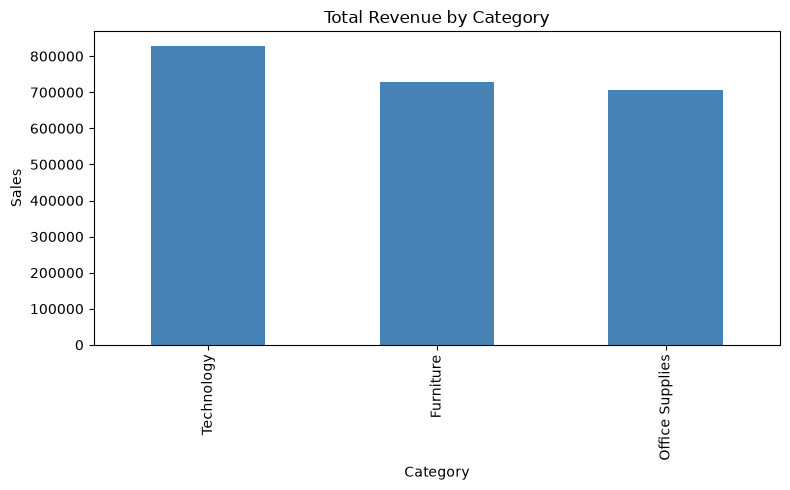

In [116]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar", color="steelblue")

plt.title("Total Revenue by Category")

plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/category_sales.png")

plt.show()

# ============================================
# Region-wise Sales Growth
# ============================================

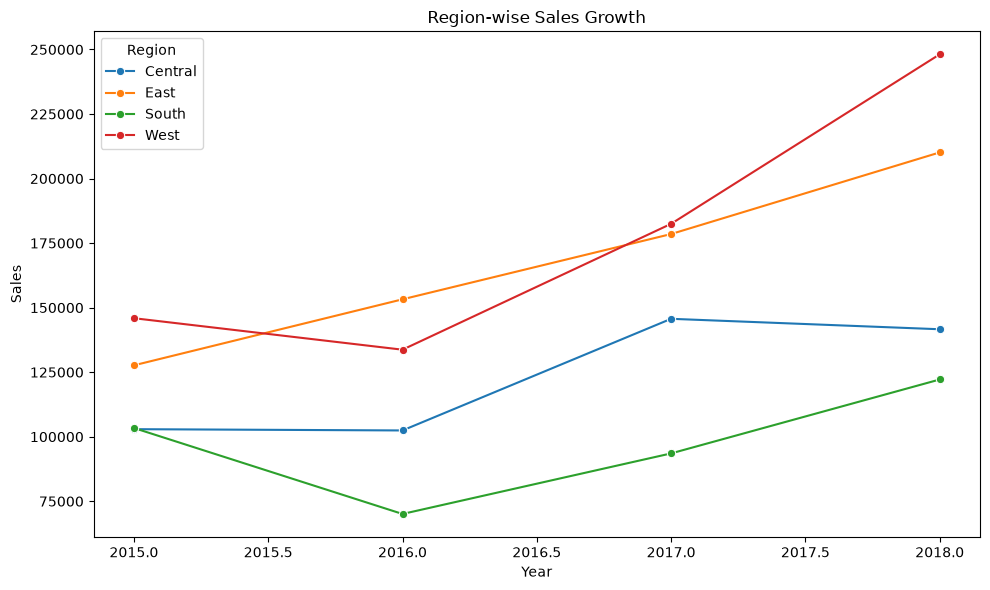

In [117]:
region_sales = df.groupby(["Year","Region"])["Sales"].sum().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Region-wise Sales Growth")

plt.tight_layout()

plt.savefig("charts/region_growth.png")

plt.show()

# ============================================
# Shipping Time Analysis
# ============================================

In [118]:

df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

print("Average Shipping Days")

print(df["Shipping Days"].mean())

print("\nShipping Days by Region")

print(df.groupby("Region")["Shipping Days"].mean())

Average Shipping Days
3.9611224489795918

Shipping Days by Region
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


# ============================================
# Monthly Sales
# ============================================


Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


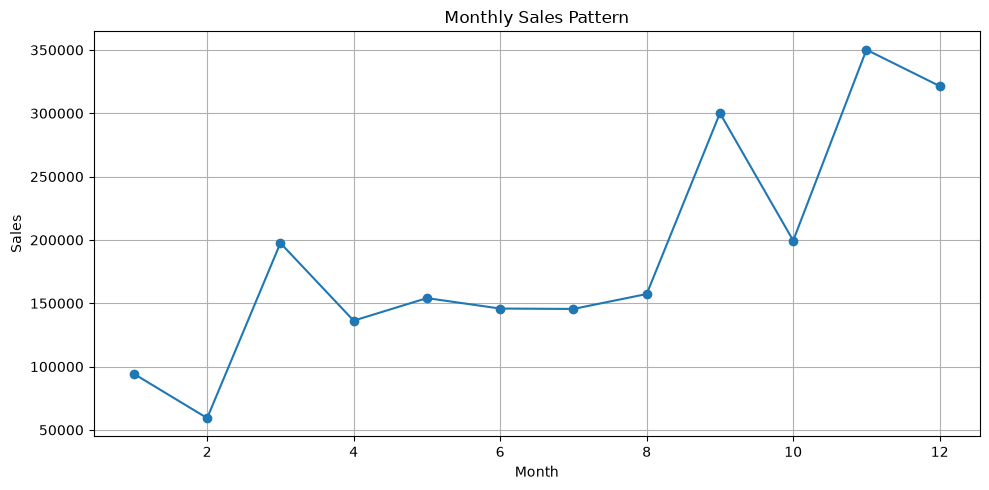

In [119]:
monthly_pattern = df.groupby("Month")["Sales"].sum()

print(monthly_pattern)

plt.figure(figsize=(10,5))

monthly_pattern.plot(marker="o")

plt.title("Monthly Sales Pattern")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid()

plt.tight_layout()

plt.savefig("charts/monthly_pattern.png")

plt.show()

In [120]:
print("""
Business Observations

1. The category with the highest total revenue is shown in the category sales chart.

2. The region with the most stable sales trend can be identified from the region-wise growth graph.

3. Average shipping time is calculated using the difference between Ship Date and Order Date.

4. Monthly sales trends indicate seasonal demand, with certain months consistently generating higher sales.
""")


Business Observations

1. The category with the highest total revenue is shown in the category sales chart.

2. The region with the most stable sales trend can be identified from the region-wise growth graph.

3. Average shipping time is calculated using the difference between Ship Date and Order Date.

4. Monthly sales trends indicate seasonal demand, with certain months consistently generating higher sales.



# Task 2: Time Series Analysis & Decomposition

# ============================================
# Monthly Sales Trend
# ============================================


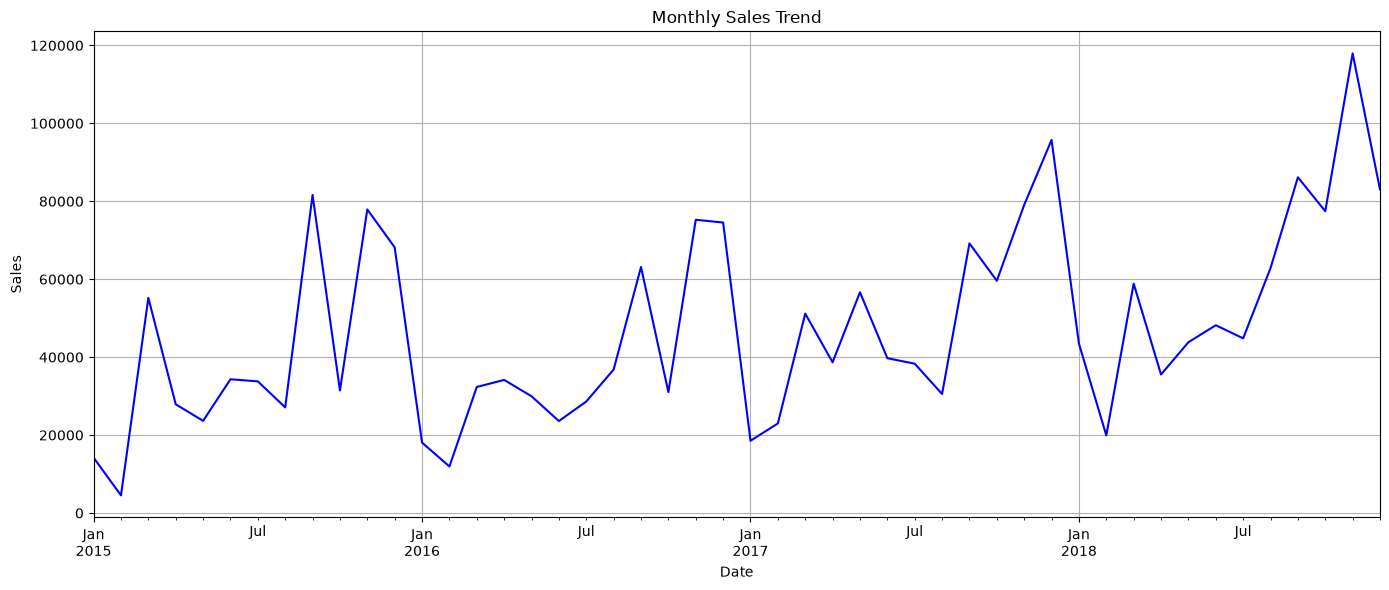

In [121]:
plt.figure(figsize=(14,6))

monthly_sales.plot(color="blue")

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png")

plt.show()

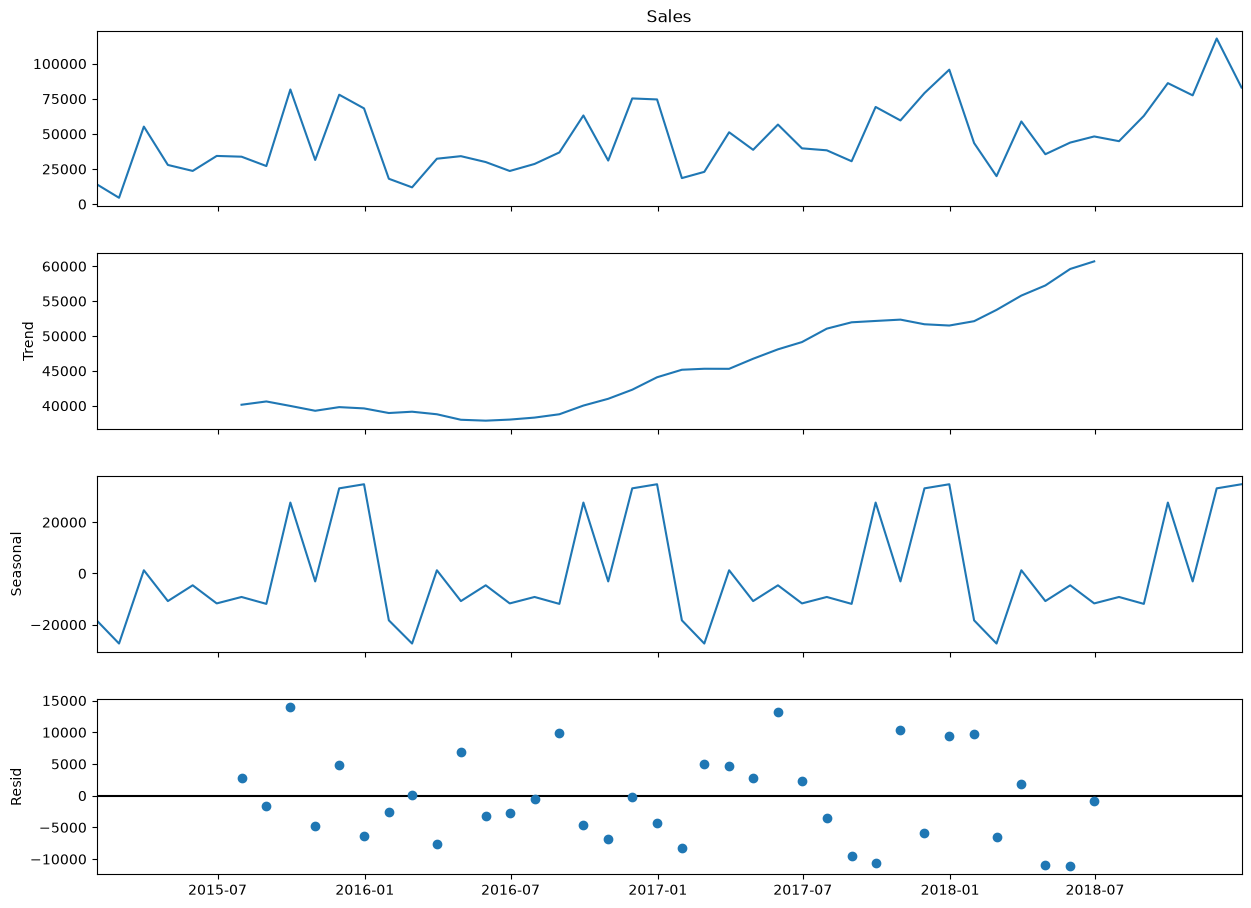

In [122]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.savefig("charts/time_series_decomposition.png")

plt.show()

In [123]:
print("""
Time Series Observations

1. The trend component shows the long-term movement in sales.

2. The seasonal component identifies recurring yearly sales patterns.

3. The residual component contains random fluctuations not explained by trend or seasonality.

4. Strong seasonality indicates predictable demand cycles that improve forecasting accuracy.
""")


Time Series Observations

1. The trend component shows the long-term movement in sales.

2. The seasonal component identifies recurring yearly sales patterns.

3. The residual component contains random fluctuations not explained by trend or seasonality.

4. Strong seasonality indicates predictable demand cycles that improve forecasting accuracy.



In [124]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [125]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

The time series is stationary.


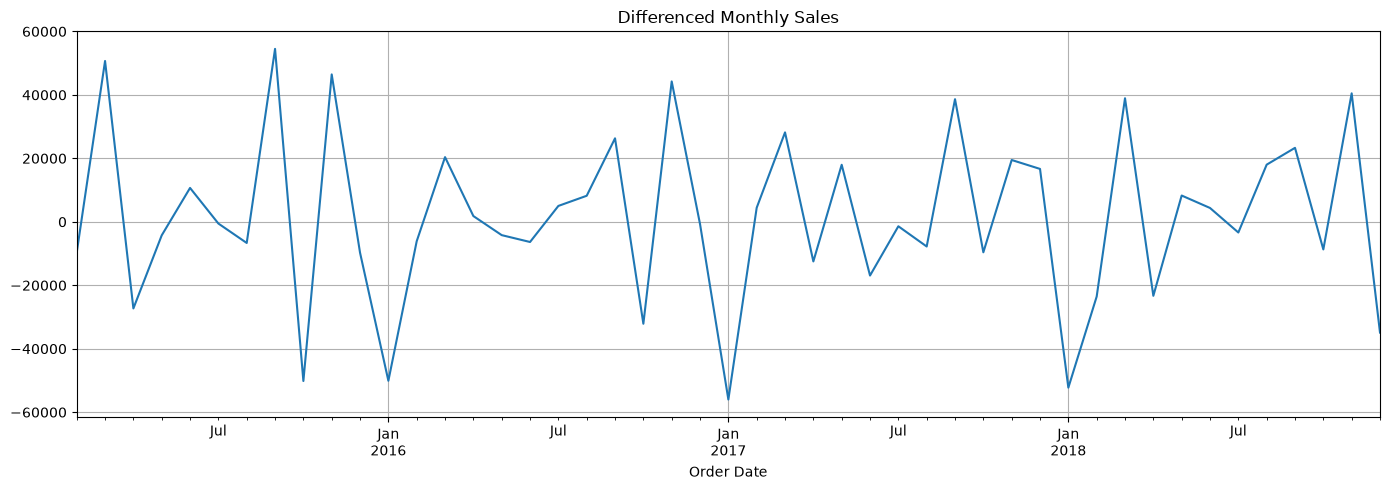

In [126]:
monthly_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(14,5))

monthly_diff.plot()

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/differenced_series.png")

plt.show()

In [127]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :", result2[0])

print("p-value :", result2[1])

ADF Statistic : -8.727061830353264
p-value : 3.2669175472797e-14


In [128]:
print("""
Stationarity Summary

If the p-value is less than 0.05 after differencing,
the series is considered stationary and suitable for
forecasting models such as SARIMA.
""")


Stationarity Summary

If the p-value is less than 0.05 after differencing,
the series is considered stationary and suitable for
forecasting models such as SARIMA.



# Task 3: Sales Forecasting using 3 Different Models

# ============================================
# Train-Test Split
# ============================================

In [129]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training Months :", len(train))
print("Testing Months :", len(test))

Training Months : 45
Testing Months : 3


In [130]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Sun, 05 Jul 2026   AIC                            705.958
Time:                                    16:27:09   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [131]:
sarima_forecast = sarima_model.forecast(3)

print(sarima_forecast)

2018-10-31    66177.602484
2018-11-30    92049.249687
2018-12-31    99965.168733
Freq: ME, Name: predicted_mean, dtype: float64


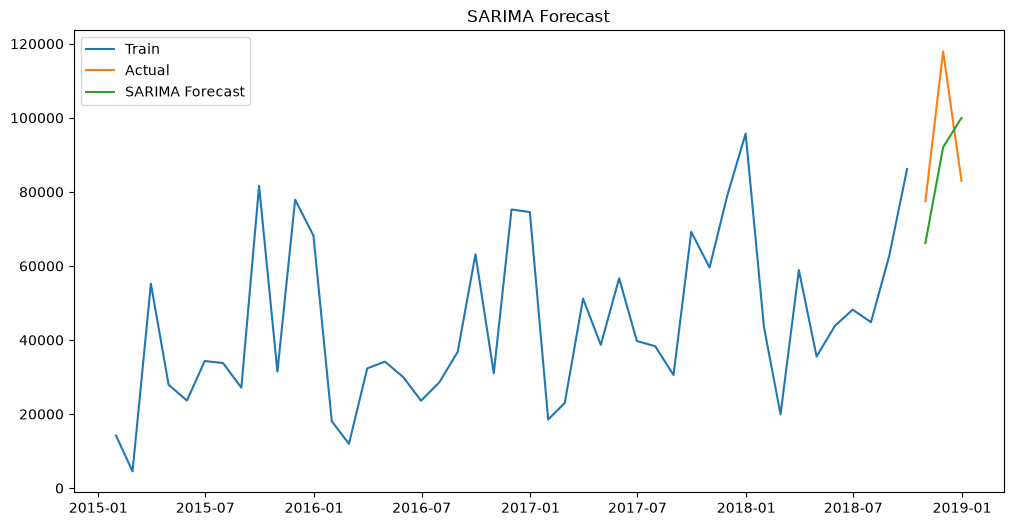

In [132]:
plt.figure(figsize=(12,6))

plt.plot(train.index,train,label="Train")

plt.plot(test.index,test,label="Actual")

plt.plot(test.index,sarima_forecast,label="SARIMA Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.savefig("charts/sarima_forecast.png")

plt.show()

In [133]:
from prophet import Prophet

prophet_df = monthly_sales.reset_index()

prophet_df.columns=["ds","y"]

train_prophet = prophet_df[:-3]

model = Prophet()

model.fit(train_prophet)

16:27:10 - cmdstanpy - INFO - Chain [1] start processing
16:27:11 - cmdstanpy - INFO - Chain [1] done processing


In [134]:
future = model.make_future_dataframe(periods=3,freq="ME")

forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277844,38959.965284,55671.996696,54942.277844,54942.277844,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557365
44,2018-09-30,55441.608235,78620.488897,94906.477880,55441.608235,55441.608235,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953607
45,2018-10-31,55957.582974,42722.525501,59716.998523,55957.415027,55957.759409,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944624
46,2018-11-30,56456.913365,82688.112049,98814.211552,56456.352494,56457.514465,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653905
47,2018-12-31,56972.888104,82253.714806,98426.775551,56971.792948,56974.072081,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084688


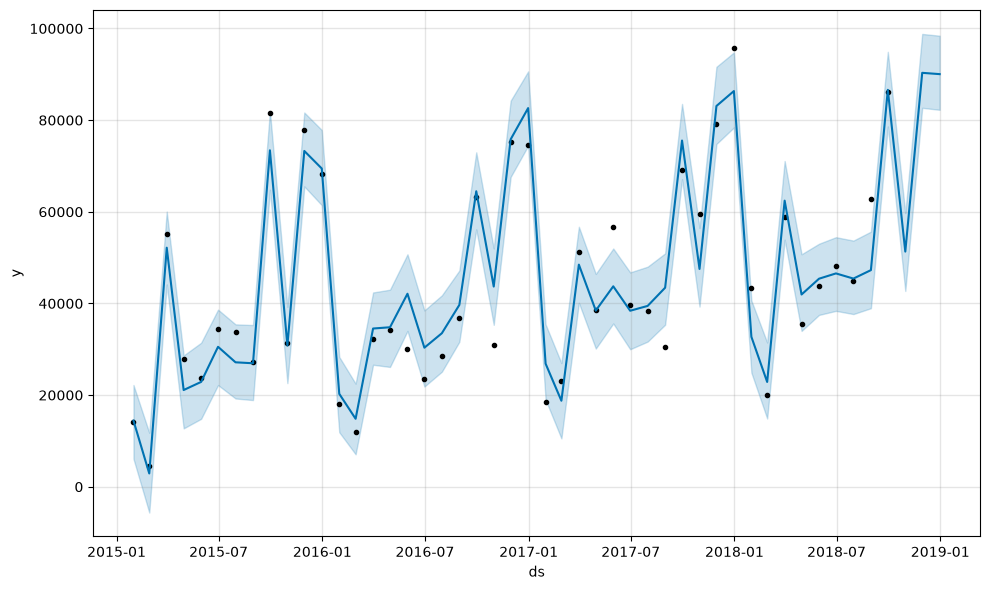

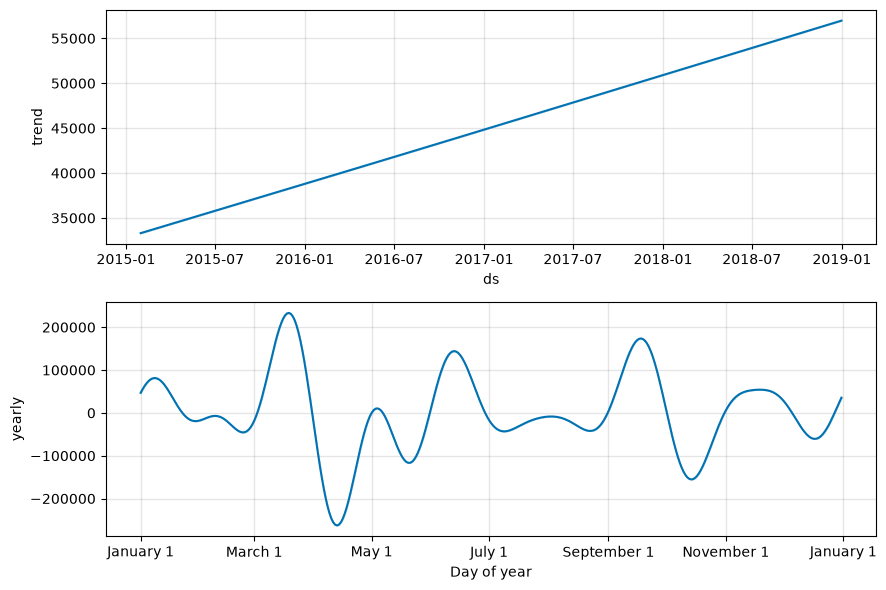

In [135]:
model.plot(forecast)

plt.savefig("charts/prophet_forecast.png")

plt.show()

model.plot_components(forecast)

plt.savefig("charts/prophet_components.png")

plt.show()

In [136]:
xgb_df = monthly_sales.to_frame()

xgb_df["Lag1"]=xgb_df["Sales"].shift(1)
xgb_df["Lag2"]=xgb_df["Sales"].shift(2)
xgb_df["Lag3"]=xgb_df["Sales"].shift(3)

xgb_df["RollingMean"]=xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"]=xgb_df.index.month
xgb_df["Quarter"]=xgb_df.index.quarter

xgb_df=xgb_df.dropna()

In [137]:
from xgboost import XGBRegressor

X=xgb_df.drop("Sales",axis=1)

y=xgb_df["Sales"]

X_train=X[:-3]
X_test=X[-3:]

y_train=y[:-3]
y_test=y[-3:]

xgb=XGBRegressor()

xgb.fit(X_train,y_train)

xgb_pred=xgb.predict(X_test)

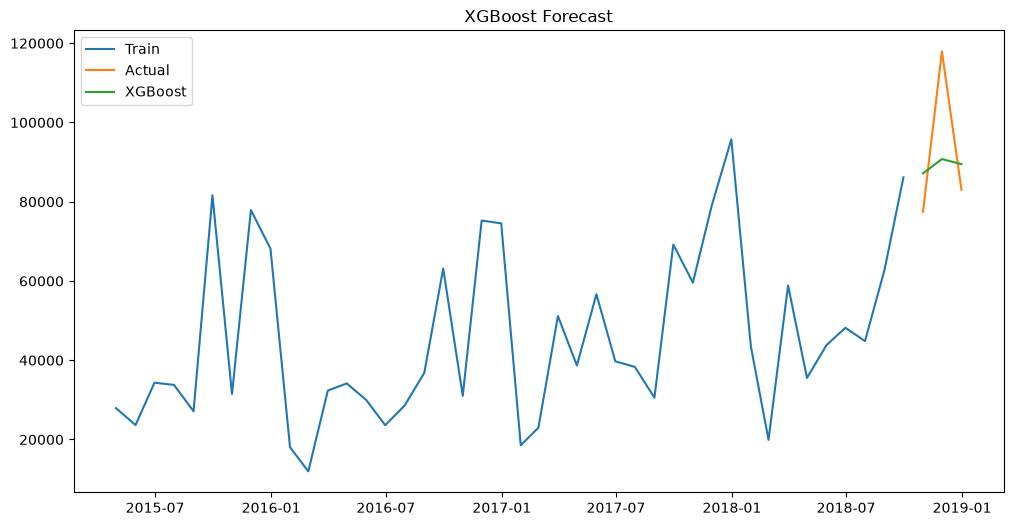

In [138]:
plt.figure(figsize=(12,6))

plt.plot(y_train.index,y_train,label="Train")

plt.plot(y_test.index,y_test,label="Actual")

plt.plot(y_test.index,xgb_pred,label="XGBoost")

plt.legend()

plt.title("XGBoost Forecast")

plt.savefig("charts/xgboost_forecast.png")

plt.show()

In [139]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

results=pd.DataFrame({

"Model":[
"SARIMA",
"Prophet",
"XGBoost"
],

"MAE":[
mean_absolute_error(test,sarima_forecast),
mean_absolute_error(test,forecast["yhat"].tail(3)),
mean_absolute_error(y_test,xgb_pred)
],

"RMSE":[
np.sqrt(mean_squared_error(test,sarima_forecast)),
np.sqrt(mean_squared_error(test,forecast["yhat"].tail(3))),
np.sqrt(mean_squared_error(y_test,xgb_pred))
],

"MAPE":[
mean_absolute_percentage_error(test,sarima_forecast),
mean_absolute_percentage_error(test,forecast["yhat"].tail(3)),
mean_absolute_percentage_error(y_test,xgb_pred)
]

})

print(results)

     Model           MAE          RMSE      MAPE
0   SARIMA  18031.404654  19009.182055  0.189665
1  Prophet  20250.794520  22318.411418  0.218646
2  XGBoost  14443.456458  17069.090751  0.144473


In [140]:
best=results.sort_values(
by="RMSE"
)

print(best)

print("\nRecommended Model")

print(best.iloc[0]["Model"])

     Model           MAE          RMSE      MAPE
2  XGBoost  14443.456458  17069.090751  0.144473
0   SARIMA  18031.404654  19009.182055  0.189665
1  Prophet  20250.794520  22318.411418  0.218646

Recommended Model
XGBoost


# Task 4: Product Category & Region Level Forecasting

# ============================================
# Category Forecasting
# ============================================

In [141]:
category_monthly = (
    df.groupby(["Category", pd.Grouper(key="Order Date", freq="ME")])["Sales"]
    .sum()
    .reset_index()
)

print(category_monthly.head())

    Category Order Date      Sales
0  Furniture 2015-01-31   6217.277
1  Furniture 2015-02-28   1839.658
2  Furniture 2015-03-31  14243.368
3  Furniture 2015-04-30   7944.837
4  Furniture 2015-05-31   6912.787


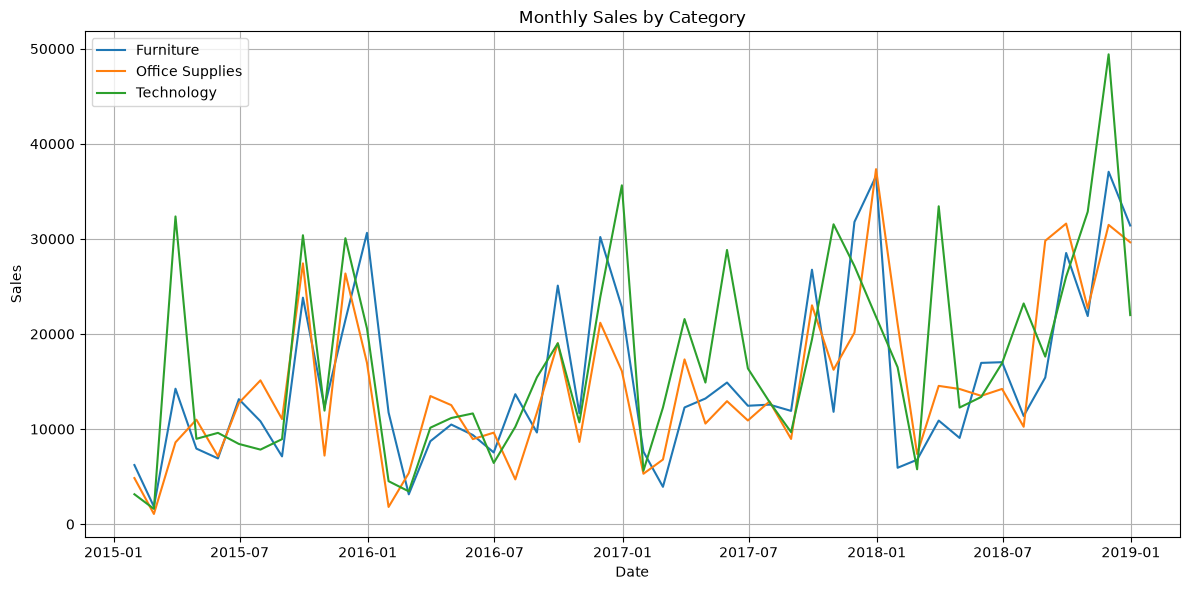

In [142]:
plt.figure(figsize=(12,6))

for category in category_monthly["Category"].unique():
    temp = category_monthly[category_monthly["Category"] == category]

    plt.plot(
        temp["Order Date"],
        temp["Sales"],
        label=category
    )

plt.title("Monthly Sales by Category")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/category_forecast.png")

plt.show()

In [143]:
region_monthly = (
    df.groupby(["Region", pd.Grouper(key="Order Date", freq="ME")])["Sales"]
    .sum()
    .reset_index()
)

print(region_monthly.head())

    Region Order Date     Sales
0  Central 2015-01-31  1533.966
1  Central 2015-02-28  1233.174
2  Central 2015-03-31  5827.602
3  Central 2015-04-30  3712.340
4  Central 2015-05-31  4044.522


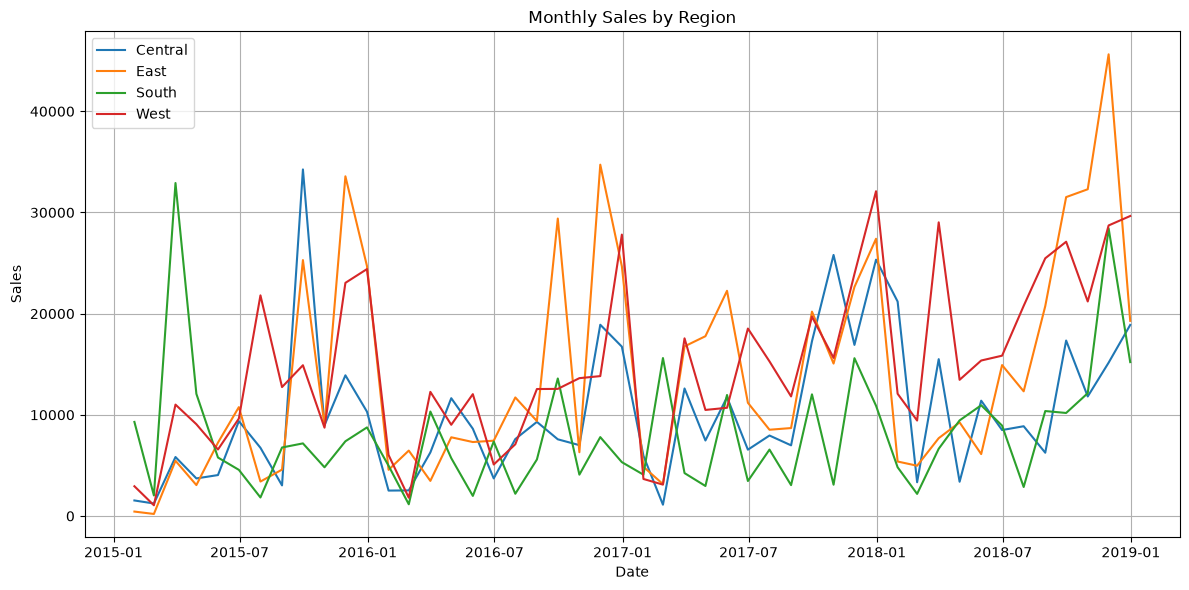

In [144]:
plt.figure(figsize=(12,6))

for region in region_monthly["Region"].unique():

    temp = region_monthly[
        region_monthly["Region"] == region
    ]

    plt.plot(
        temp["Order Date"],
        temp["Sales"],
        label=region
    )

plt.title("Monthly Sales by Region")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/region_forecast.png")

plt.show()

In [145]:
category_summary = category_monthly.groupby("Category")["Sales"].sum()

print(category_summary.sort_values(ascending=False))

region_summary = region_monthly.groupby("Region")["Sales"].sum()

print(region_summary.sort_values(ascending=False))

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [146]:
print("""
Business Observation

1. Technology, Furniture, and Office Supplies show different sales patterns over time.

2. Regional sales trends highlight differences in demand across geographic areas.

3. The category and region with the strongest sales trend should receive greater inventory planning attention.

4. Forecasting at the category and regional level supports more accurate stock management than using overall sales alone.
""")


Business Observation

1. Technology, Furniture, and Office Supplies show different sales patterns over time.

2. Regional sales trends highlight differences in demand across geographic areas.

3. The category and region with the strongest sales trend should receive greater inventory planning attention.

4. Forecasting at the category and regional level supports more accurate stock management than using overall sales alone.



# Task 5: Anomaly Detection in Sales Data

# ============================================
# Weekly Sales Aggregation
# ============================================


In [147]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


# ============================================
# Isolation Forest
# ============================================


In [148]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


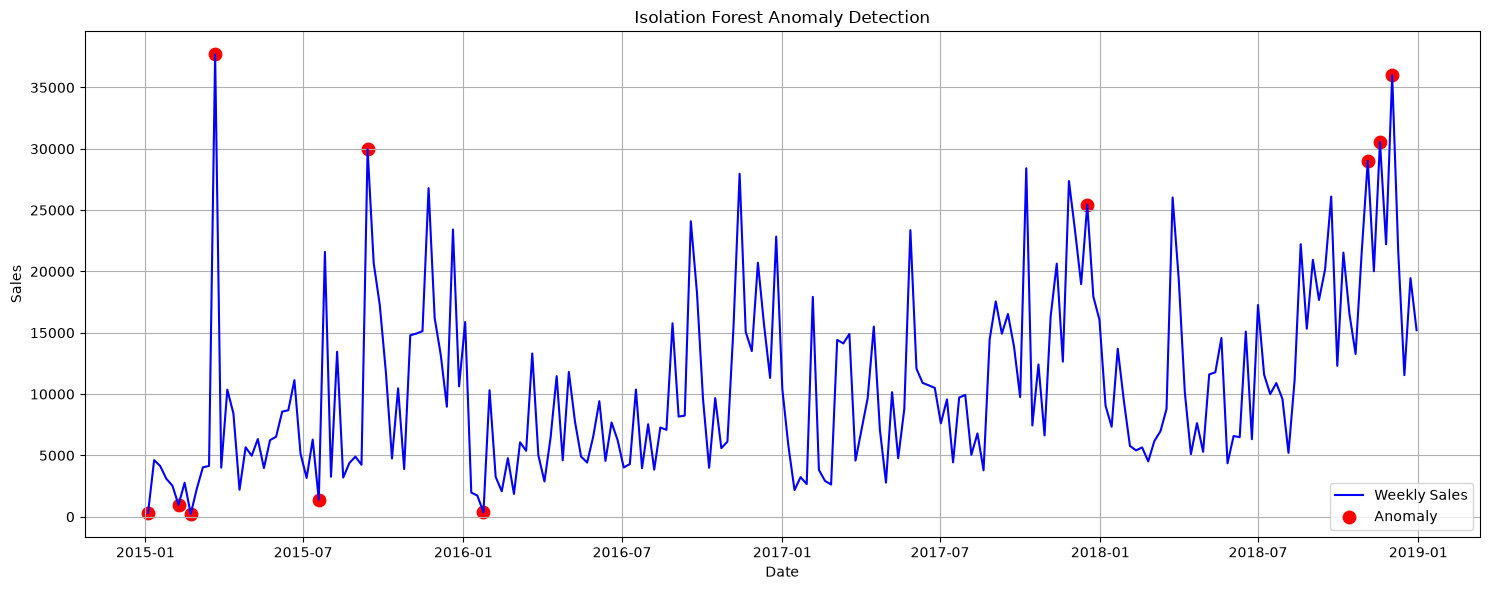

In [149]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue"
)

anomaly = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/isolation_forest.png")

plt.show()


# ============================================
# Z-Score Detection
# ============================================

In [150]:
from scipy.stats import zscore

weekly_sales["ZScore"] = zscore(
    weekly_sales["Sales"]
)

weekly_sales["Z_Anomaly"] = (
    abs(weekly_sales["ZScore"]) > 2
)

weekly_sales.head()

,Order Date,Sales,Anomaly,ZScore,Z_Anomaly
0,2015-01-04,304.508,-1,-1.423862,False
1,2015-01-11,4619.108,1,-0.839680,False
2,2015-01-18,4130.533,1,-0.905832,False
3,2015-01-25,3092.544,1,-1.046372,False
4,2015-02-01,2527.914,1,-1.122821,False


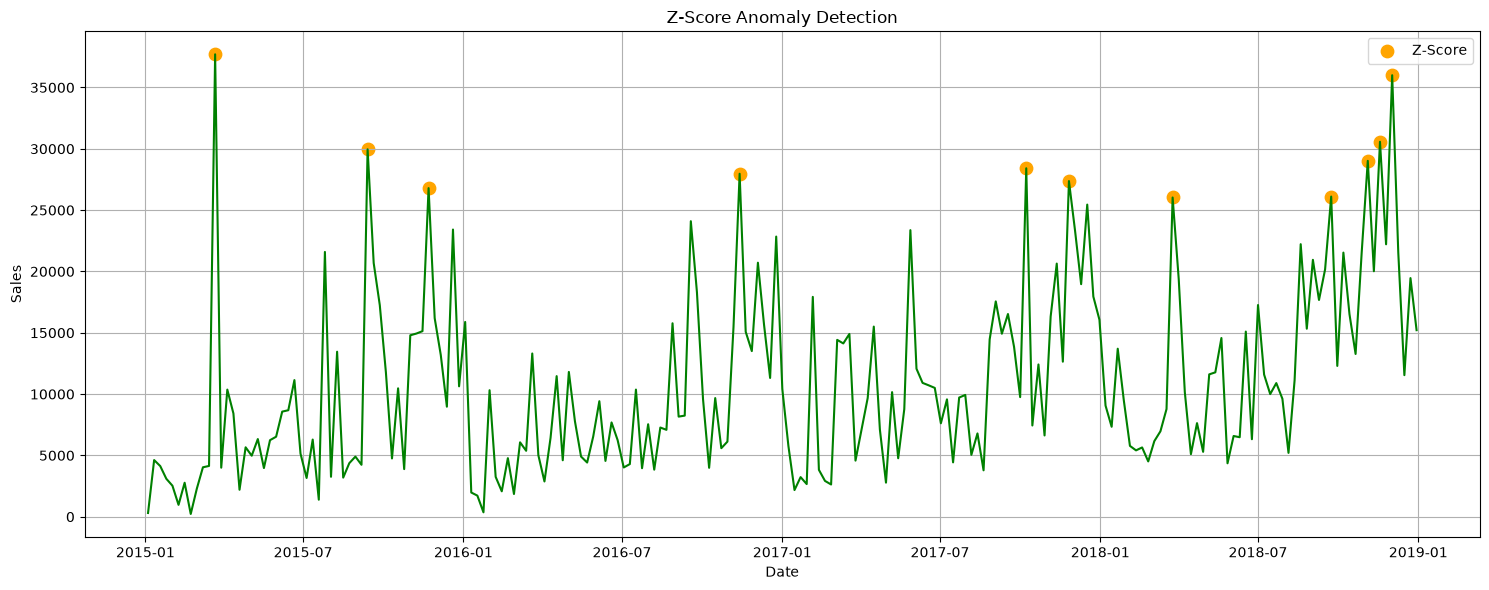

In [151]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="green"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"] == True
]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="orange",
    s=80,
    label="Z-Score"
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/zscore_anomaly.png")

plt.show()

In [152]:
print("Isolation Forest Anomalies")

print(
    weekly_sales[
        weekly_sales["Anomaly"]==-1
    ][["Order Date","Sales"]]
)

print("\n")

print("Z-Score Anomalies")

print(
    weekly_sales[
        weekly_sales["Z_Anomaly"]==True
    ][["Order Date","Sales"]]
)

Isolation Forest Anomalies
    Order Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900


Z-Score Anomalies
    Order Date       Sales
11  2015-03-22  37703.6650
36  2015-09-13  29959.1370
46  2015-11-22  26793.6235
97  2016-11-13  27965.3492
144 2017-10-08  28412.0980
151 2017-11-26  27367.7160
168 2018-03-25  26029.9040
194 2018-09-23  26104.4330
200 2018-11-04  29017.4670
202 2018-11-18  30572.4470
204 2018-12-02  35998.9000


In [153]:
print("""
Business Observations

1. Isolation Forest identified unusual weeks with extremely high or low sales.

2. Z-Score detected weeks where sales deviated significantly from the average.

3. Some anomalies were detected by both methods, while others were unique to one method.

4. Large positive spikes may correspond to festive seasons, promotional campaigns, or special discounts.

5. Large negative spikes may indicate supply shortages, holidays, logistics issues, or reduced customer demand.

6. Monitoring anomalies regularly helps businesses respond quickly to unexpected sales changes.
""")


Business Observations

1. Isolation Forest identified unusual weeks with extremely high or low sales.

2. Z-Score detected weeks where sales deviated significantly from the average.

3. Some anomalies were detected by both methods, while others were unique to one method.

4. Large positive spikes may correspond to festive seasons, promotional campaigns, or special discounts.

5. Large negative spikes may indicate supply shortages, holidays, logistics issues, or reduced customer demand.

6. Monitoring anomalies regularly helps businesses respond quickly to unexpected sales changes.



# Task 6: Product Demand Segmentation using Clustering

# ============================================
# Product Demand Segmentation
# ============================================

In [ ]:
product_data = df.groupby("Sub-Category").agg(
    TotalSales=("Sales","sum"),
    AvgSales=("Sales","mean"),
    SalesStd=("Sales","std"),
    AvgProfit=("Profit","mean"),
    TotalQuantity=("Quantity","sum")
).reset_index()

product_data.fillna(0, inplace=True)

product_data.head()

In [ ]:
from sklearn.preprocessing import StandardScaler

features = product_data.drop("Sub-Category", axis=1)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.savefig("charts/elbow_method.png")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(
    scaled_features
)

product_data.head()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_features
)

product_data["PCA1"] = pca_data[:,0]

product_data["PCA2"] = pca_data[:,1]

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=product_data,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=120
)

for i in range(len(product_data)):
    plt.text(
        product_data["PCA1"][i],
        product_data["PCA2"][i],
        product_data["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Segmentation")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/product_clusters.png")

plt.show()

print(product_data[["Sub-Category","Cluster"]])

In [ ]:
print("""
Product Demand Segmentation

Cluster 0
High Volume, Stable Demand
Recommendation:
Maintain regular inventory levels and avoid stock-outs.

Cluster 1
Growing Demand
Recommendation:
Increase purchasing and monitor future sales closely.

Cluster 2
Low Volume, High Volatility
Recommendation:
Keep limited stock and reorder based on demand.

Cluster 3
Declining Demand
Recommendation:
Reduce inventory, avoid overstocking, and consider promotional discounts.
""")